In [1]:
import pandas as pd
import numpy as np
import pymysql
from typing import Dict, List, Tuple, Optional
from DATA.stock_invest_function import get_db_host
# from US_Market.analysis.미국기업_매출_가치평가_DB_확인 import revenue_forecast

In [2]:
def get_indicator_list_from_db(db_info: Dict,
                               table_name: str = "us_required_return_result"
                               ) -> List[str]:
    """
    큰 테이블 전체를 읽지 않고,
    DB에서 DISTINCT indicator 이름만 추출.
    """
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    query = f"SELECT DISTINCT indicator FROM {table_name};"

    try:
        df = pd.read_sql(query, conn)
    finally:
        conn.close()

    return sorted(df["indicator"].dropna().tolist())

def fetch_required_return_pivot_from_db(
    db_info: Dict,
    table_name: str = "us_required_return_result",
    indicators: Optional[List[str]] = None,
    start_date: Optional[str] = None,   # "YYYY-MM-DD"
    end_date: Optional[str] = None,     # "YYYY-MM-DD"
    tickers: Optional[List[str]] = None
) -> pd.DataFrame:
    """
    us_required_return_result 테이블에서 직접 pivot 형태로 SELECT.

    - index: date, ticker
    - columns: indicator 이름들
    - values: value (MAX(CASE WHEN ...) 사용)

    큰 테이블 전체를 안 읽고, SQL에서 집계해서 가져오기 때문에 메모리 부담이 훨씬 적다.
    """

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        # 1) indicator 리스트가 안 들어오면, DB에서 DISTINCT로 먼저 가져오기
        if indicators is None:
            indicators = get_indicator_list_from_db(db_info, table_name)

        # 2) indicator별 CASE WHEN 절 만들기
        case_clauses = []
        for ind in indicators:
            # 컬럼 alias에 공백/특수문자가 있으면 쿼리가 깨질 수 있으므로 간단히 감싸줌
            safe_alias = ind.replace("`", "")  # 백틱 제거
            clause = f"MAX(CASE WHEN indicator = %s THEN value END) AS `{safe_alias}`"
            case_clauses.append(clause)

        case_sql = ",\n       ".join(case_clauses)

        # 3) WHERE 절 동적으로 생성
        where_clauses = []
        params = []

        if start_date is not None:
            where_clauses.append("date >= %s")
            params.append(start_date)

        if end_date is not None:
            where_clauses.append("date <= %s")
            params.append(end_date)

        if tickers is not None and len(tickers) > 0:
            # IN (%s, %s, ...)
            tick_placeholders = ", ".join(["%s"] * len(tickers))
            where_clauses.append(f"ticker IN ({tick_placeholders})")
            params.extend(tickers)

        where_sql = ""
        if where_clauses:
            where_sql = "WHERE " + " AND ".join(where_clauses)

        # 4) 전체 쿼리 조립
        #    date, ticker별로 indicator를 열로 펼친 형태
        query = f"""
            SELECT
                date,
                ticker,
                {case_sql}
            FROM {table_name}
            {where_sql}
            GROUP BY date, ticker
            ORDER BY date, ticker;
        """

        # indicator 값들을 CASE WHEN의 %s에 넣어줌
        # CASE WHEN indicator = %s THEN value END  → 각 indicator마다 하나씩
        case_params = indicators[:]  # 각 CASE WHEN 한 번씩
        all_params = case_params + params

        df_pivot = pd.read_sql(query, conn, params=all_params)

        # date를 datetime으로 변환 (필요시)
        df_pivot["date"] = pd.to_datetime(df_pivot["date"])
        return df_pivot

    finally:
        conn.close()


def fetch_sec_financial_item_pivot(
    db_info: Dict,
    item_name: str,
    table_name: str = "sec_financial_data",
    tickers: Optional[List[str]] = None,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None
) -> pd.DataFrame:
    """
    sec_financial_data 테이블에서 item_name과 ticker를 입력하면
    date | ticker | <item_name> 형태의 pivot-like DataFrame을 반환.
    """

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        # 1. 동적 WHERE 조건 생성
        where_clauses = ["item_name = %s"]
        params: List = [item_name]

        if tickers:
            placeholders = ", ".join(["%s"] * len(tickers))
            where_clauses.append(f"ticker IN ({placeholders})")
            params.extend(tickers)

        if start_date:
            where_clauses.append("date >= %s")
            params.append(start_date)

        if end_date:
            where_clauses.append("date <= %s")
            params.append(end_date)

        where_sql = "WHERE " + " AND ".join(where_clauses)

        # 2. SQL 실행
        query = f"""
            SELECT
                date,
                ticker,
                value
            FROM {table_name}
            {where_sql}
            ORDER BY date, ticker;
        """

        df = pd.read_sql(query, conn, params=params)

    finally:
        conn.close()

    # 빈 데이터 처리
    if df.empty:
        print(f"[WARN] No data for item_name={item_name}, tickers={tickers}")
        return df

    # date 컬럼을 datetime 형태로 변환
    df["date"] = pd.to_datetime(df["date"])

    # value → item_name 으로 컬럼명 변경
    df = df.rename(columns={"value": item_name})

    # pivot-like format 유지
    df = df[["date", "ticker", item_name]]

    return df


def get_top_tickers_by_latest_item(
    db_info: Dict,
    item_name: str,
    top_n: int = 20,
    table_name: str = "sec_financial_data",
) -> pd.DataFrame:
    """
    sec_financial_data 테이블에서
    - 특정 item_name에 대해
    - ticker별 '가장 최근 date'의 value를 가져오고
    - value가 큰 순서대로 상위 top_n개를 반환.

    반환 컬럼: rank, ticker, item_name, date, value
    """

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        # 서브쿼리로 ticker별 최신 날짜 구하고 join
        query = f"""
            SELECT
                s.ticker,
                s.item_name,
                s.date,
                s.value
            FROM {table_name} AS s
            JOIN (
                SELECT
                    ticker,
                    MAX(date) AS max_date
                FROM {table_name}
                WHERE item_name = %s
                GROUP BY ticker
            ) AS t
              ON s.ticker = t.ticker
             AND s.date   = t.max_date
            WHERE s.item_name = %s
            ORDER BY s.value DESC
            LIMIT %s;
        """

        params = (item_name, item_name, top_n)
        df = pd.read_sql(query, conn, params=params)

    finally:
        conn.close()

    if df.empty:
        print(f"[WARN] item_name={item_name} 에 해당하는 데이터가 없습니다.")
        return df

    # rank 컬럼 추가 (1위부터)
    df.insert(0, "rank", range(1, len(df) + 1))

    # date를 datetime으로 변환(원하시면)
    df["date"] = pd.to_datetime(df["date"])

    return df

In [3]:
# 1) DB 설정
db_info = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",   # 실제 비밀번호
    "database": "investar",
}

In [4]:
indicators = get_indicator_list_from_db(db_info, "us_required_return_result")
print("indicator 목록:", indicators)

indicator 목록: ['E_Rm_1y', 'E_Rm_3y', 'E_Rm_5y', 'Re_1y', 'Re_3y', 'Re_5y', 'beta_1250', 'beta_252', 'beta_750', 'price_mkt', 'price_stock', 'ret_mkt', 'ret_stock', 'rf_1y', 'rf_3y', 'rf_5y']


In [5]:
company_ticker = 'MU'
item_name = 'roe'

tickers = ['MU']

re_df = fetch_required_return_pivot_from_db(
    db_info=db_info,
    table_name="us_required_return_result",
    indicators=['Re_5y'],        # ← 리스트로!
    start_date="2020-01-01",
    end_date=None,
    tickers=tickers
)

print(re_df.head())

        date ticker     Re_5y
0 2020-01-02     MU  0.182094
1 2020-01-03     MU  0.183570
2 2020-01-06     MU  0.180062
3 2020-01-07     MU  0.178052
4 2020-01-08     MU  0.177549


In [6]:
# 예: Re_5y indicator 만 가져오기
roe_df = fetch_sec_financial_item_pivot(
    db_info=db_info,
    item_name="roe",
    tickers=tickers,
    start_date="2020-01-01"
)

roe_df['roe'] = roe_df['roe']/100

In [7]:

# 1. roe_df를 월말로 전환하고 실제 월말 날짜로 통일
roe_df['date'] = pd.to_datetime(roe_df['date'])
roe_df['month_end'] = roe_df['date'] + pd.offsets.MonthEnd(0)
roe_df = roe_df.drop('date', axis=1).rename(columns={'month_end': 'date'})

# 날짜 범위 확인
roe_start = roe_df['date'].min()
roe_end = roe_df['date'].max()

# 전체 월말 날짜 범위 생성
all_month_ends = pd.date_range(start=roe_start, end=roe_end, freq='ME')
all_tickers = roe_df['ticker'].unique()

# 모든 ticker와 월말 조합 생성
full_index = pd.MultiIndex.from_product([all_tickers, all_month_ends],
                                         names=['ticker', 'date'])
roe_df_full = pd.DataFrame(index=full_index).reset_index()

# 원본 데이터와 병합
roe_df_full = roe_df_full.merge(roe_df, on=['ticker', 'date'], how='left')

# 분기별 데이터를 ffill(limit=2)로 채우기
roe_df_full = roe_df_full.sort_values(['ticker', 'date'])
roe_df_full['roe'] = roe_df_full.groupby('ticker')['roe'].ffill(limit=2)

# NaN 제거 (ffill 이후에도 채워지지 않은 행)
roe_df_full = roe_df_full.dropna(subset=['roe'])

print("roe_df 처리 완료:")
print(roe_df_full.head(10))
print(f"\nroe_df 날짜 범위: {roe_df_full['date'].min()} ~ {roe_df_full['date'].max()}")

# 2. re_df를 월말로 추출하고 실제 월말 날짜로 통일
re_df['date'] = pd.to_datetime(re_df['date'])
re_df['month_end'] = re_df['date'] + pd.offsets.MonthEnd(0)

# 월말 데이터만 추출 (각 월의 마지막 거래일)
re_df_monthly = re_df.groupby(['ticker', 'month_end']).last().reset_index()
re_df_monthly = re_df_monthly.drop('date', axis=1).rename(columns={'month_end': 'date'})

print("\nre_df 처리 완료:")
print(re_df_monthly.head(10))
print(f"\nre_df 날짜 범위: {re_df_monthly['date'].min()} ~ {re_df_monthly['date'].max()}")

# 3. 두 데이터프레임 결합 (re_df_monthly 기준 left join)
roe_re_df = pd.merge(re_df_monthly, roe_df_full,
                     on=["ticker", "date"],
                     how="left")

# 4. 결합 후 roe를 다시 ffill(limit=2)로 채우기
roe_re_df = roe_re_df.sort_values(['ticker', 'date'])
roe_re_df['roe'] = roe_re_df.groupby('ticker')['roe'].ffill(limit=2)

# 5. ri_rate 계산 (roe와 Re_5y 모두 있는 경우만)
roe_re_df['ri_rate'] = roe_re_df['roe'] - roe_re_df['Re_5y']

print("\n결합 및 재처리 결과:")
print(roe_re_df.head(15))
print(f"\n결합된 데이터 행 수: {len(roe_re_df)}")
print(f"결합된 데이터 날짜 범위: {roe_re_df['date'].min()} ~ {roe_re_df['date'].max()}")

# NaN 확인
print(f"\nroe NaN 개수: {roe_re_df['roe'].isna().sum()}")
print(f"Re_5y NaN 개수: {roe_re_df['Re_5y'].isna().sum()}")
print(f"ri_rate NaN 개수: {roe_re_df['ri_rate'].isna().sum()}")

# 날짜별 데이터 개수 확인
print("\n날짜별 데이터 개수 (처음 10개):")
print(roe_re_df.groupby('date').size().head(10))

roe_df 처리 완료:
   ticker       date       roe
0      MU 2020-02-29  0.064171
1      MU 2020-03-31  0.064171
2      MU 2020-04-30  0.064171
3      MU 2020-05-31  0.061797
4      MU 2020-06-30  0.061797
5      MU 2020-07-31  0.061797
7      MU 2020-09-30  0.071771
8      MU 2020-10-31  0.071771
9      MU 2020-11-30  0.071771
10     MU 2020-12-31  0.078501

roe_df 날짜 범위: 2020-02-29 00:00:00 ~ 2025-11-30 00:00:00

re_df 처리 완료:
  ticker       date     Re_5y
0     MU 2020-01-31  0.167174
1     MU 2020-02-29  0.140447
2     MU 2020-03-31  0.090609
3     MU 2020-04-30  0.129890
4     MU 2020-05-31  0.144453
5     MU 2020-06-30  0.149923
6     MU 2020-07-31  0.170197
7     MU 2020-08-31  0.213270
8     MU 2020-09-30  0.188061
9     MU 2020-10-31  0.171158

re_df 날짜 범위: 2020-01-31 00:00:00 ~ 2026-02-28 00:00:00

결합 및 재처리 결과:
   ticker       date     Re_5y       roe   ri_rate
0      MU 2020-01-31  0.167174       NaN       NaN
1      MU 2020-02-29  0.140447  0.064171 -0.076276
2      MU 2020-03-31 

In [8]:
roe_df_full.tail(12)

,ticker,date,roe
58,MU,2024-12-31,0.074195
59,MU,2025-01-31,0.074195
60,MU,2025-02-28,0.089013
61,MU,2025-03-31,0.089013
62,MU,2025-04-30,0.089013
63,MU,2025-05-31,0.119402
64,MU,2025-06-30,0.119402
65,MU,2025-07-31,0.119402
66,MU,2025-08-31,0.145484
67,MU,2025-09-30,0.145484


In [9]:
re_df_monthly.tail(12)

,ticker,date,Re_5y
62,MU,2025-03-31,0.226283
63,MU,2025-04-30,0.215228
64,MU,2025-05-31,0.203080
65,MU,2025-06-30,0.224810
66,MU,2025-07-31,0.212349
67,MU,2025-08-31,0.223421
68,MU,2025-09-30,0.229244
69,MU,2025-10-31,0.227426
70,MU,2025-11-30,0.239997
71,MU,2025-12-31,0.227884


In [10]:
roe_re_df.tail(12)

,ticker,date,Re_5y,roe,ri_rate
62,MU,2025-03-31,0.226283,0.089013,-0.137270
63,MU,2025-04-30,0.215228,0.089013,-0.126215
64,MU,2025-05-31,0.203080,0.119402,-0.083678
65,MU,2025-06-30,0.224810,0.119402,-0.105408
66,MU,2025-07-31,0.212349,0.119402,-0.092947
67,MU,2025-08-31,0.223421,0.145484,-0.077937
68,MU,2025-09-30,0.229244,0.145484,-0.083760
69,MU,2025-10-31,0.227426,0.145484,-0.081942
70,MU,2025-11-30,0.239997,0.200619,-0.039378
71,MU,2025-12-31,0.227884,0.200619,-0.027265


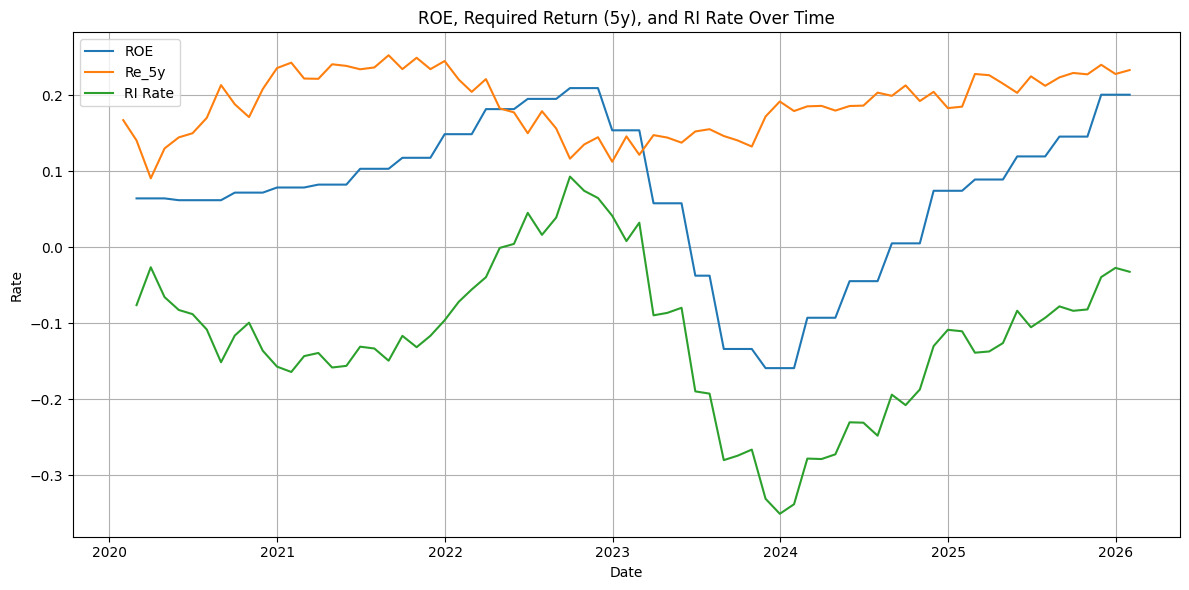

In [11]:
import matplotlib.pyplot as plt

# date를 datetime으로 변환 (안 되어 있을 경우 대비)
roe_re_df['date'] = pd.to_datetime(roe_re_df['date'])
# index 설정
df_plot = roe_re_df.set_index('date').sort_index()

plt.figure(figsize=(12, 6))

plt.plot(df_plot.index, df_plot['roe'], label='ROE')
plt.plot(df_plot.index, df_plot['Re_5y'], label='Re_5y')
plt.plot(df_plot.index, df_plot['ri_rate'], label='RI Rate')

plt.title('ROE, Required Return (5y), and RI Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [12]:
def get_unique_item_names(db_info, table_name="sec_financial_data"):
    """
    sec_financial_data 테이블에서 item_name의 unique 값 조회
    """
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info.get("port", 3306),
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        sql = f"""
        SELECT DISTINCT item_name
        FROM {table_name}
        WHERE item_name IS NOT NULL
        ORDER BY item_name
        """
        df = pd.read_sql(sql, conn)
    finally:
        conn.close()

    return df

item_df = get_unique_item_names(db_info)
print(item_df)


                           item_name
0                   accounts_payable
1                accounts_receivable
2                accrued_liabilities
3           accumulated_depreciation
4                     asset_turnover
5               capital_expenditures
6                               cash
7                    cost_of_revenue
8                     current_assets
9                current_liabilities
10                     current_ratio
11                    days_inventory
12                  days_receivables
13                    debt_to_assets
14                    debt_to_equity
15                  deferred_revenue
16         depreciation_amortization
17                 equity_multiplier
18                          goodwill
19                      gross_margin
20                      gross_profit
21                income_tax_expense
22                 intangible_assets
23                  interest_expense
24                   interest_income
25                         inventory
2

<AxesSubplot: >

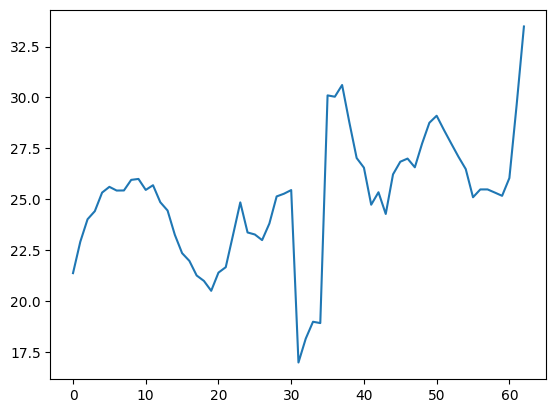

In [13]:

# 예: Re_5y indicator 만 가져오기
df = fetch_sec_financial_item_pivot(
    db_info=db_info,
    item_name= item_name,
    tickers=[company_ticker],
    start_date="2010-01-01"
)

df[item_name].plot()

In [14]:
rev_df = fetch_sec_financial_item_pivot(
    db_info=db_info,
    item_name="revenue",
    tickers=tickers,
    start_date="2020-01-01"
)


op_df = fetch_sec_financial_item_pivot(
    db_info=db_info,
    item_name="operating_income",
    tickers=tickers,
    start_date="2020-01-01"
)

In [15]:
reg_df = pd.merge(rev_df, op_df[['date', 'operating_income']], on = 'date', how='left')

In [16]:
reg_df.tail(5)

,date,ticker,revenue,operating_income
18,2024-09-30,STRL,593741000.0,87492000.0
19,2024-12-31,STRL,593741000.0,87492000.0
20,2025-03-31,STRL,430949000.0,56076000.0
21,2025-06-30,STRL,614468000.0,104564000.0
22,2025-09-30,STRL,689019000.0,125309000.0


--- [APH] 재무 항목 선형 회귀 분석 결과 ---
기울기 (Slope): 0.2515
절편 (Intercept): -69,054,237
결정계수 (R-squared): 0.8118
추정 공식: Operating Income = 0.2515 * Revenue + (-69,054,237)


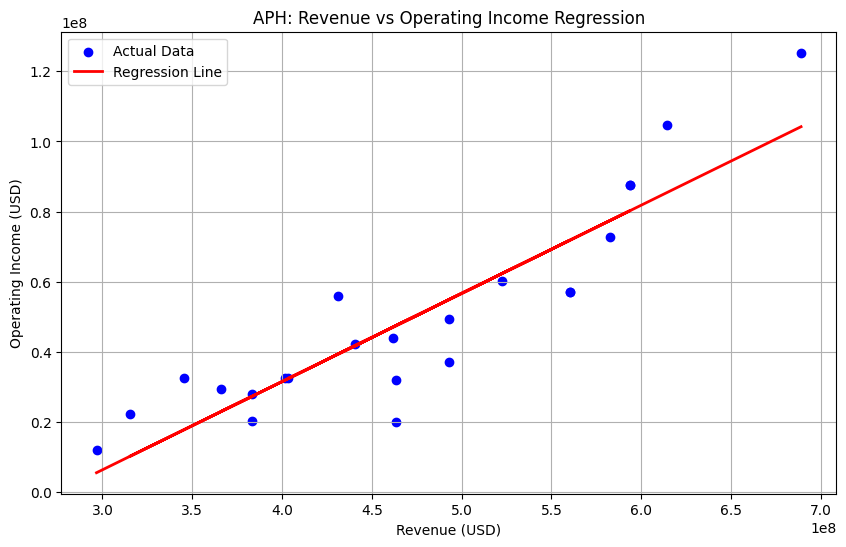

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = reg_df.copy()

# 2. X(독립변수: 매출), Y(종속변수: 영업이익) 설정
# Scikit-learn의 입력값은 2차원 배열 형태여야 하므로 reshape(-1, 1) 처리
X = df['revenue'].values.reshape(-1, 1)
y = df['operating_income'].values

# 3. 선형 회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)

# 4. 분석 결과 도출
slope = model.coef_[0]         # 기울기 (한 단위 매출 증가 시 영업이익 증가량)
intercept = model.intercept_   # 절편
y_pred = model.predict(X)      # 회귀선을 위한 예측값
r_squared = r2_score(y, y_pred) # 결정계수 (모델의 설명력)

print(f"--- [APH] 재무 항목 선형 회귀 분석 결과 ---")
print(f"기울기 (Slope): {slope:.4f}")
print(f"절편 (Intercept): {intercept:,.0f}")
print(f"결정계수 (R-squared): {r_squared:.4f}")
print(f"추정 공식: Operating Income = {slope:.4f} * Revenue + ({intercept:,.0f})")

# 5. 시각화
plt.figure(figsize=(10, 6))
plt.scatter(df['revenue'], df['operating_income'], color='blue', label='Actual Data')
plt.plot(df['revenue'], y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Revenue (USD)')
plt.ylabel('Operating Income (USD)')
plt.title(f'APH: Revenue vs Operating Income Regression')
plt.legend()
plt.grid(True)
plt.show()

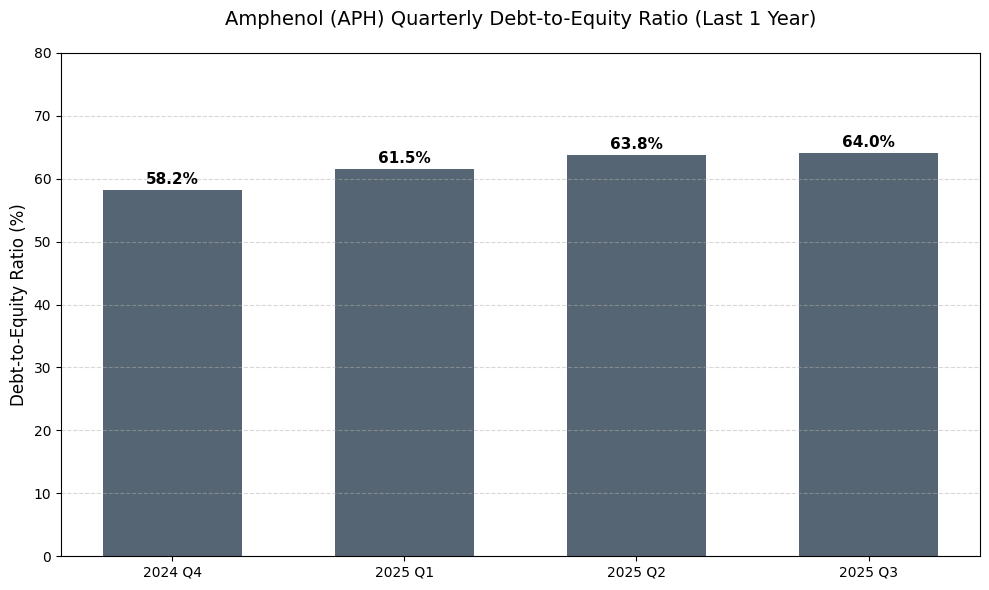

In [18]:
# 1. 최근 1년 분기별 부채비율 데이터 (회계연도 기준)
# 2025년 3분기(MRQ) 데이터를 포함한 최근 4분기 추이
quarters = ['2024 Q4', '2025 Q1', '2025 Q2', '2025 Q3']
debt_to_equity = [58.2, 61.5, 63.8, 64.0]  # 단위: % (시장 데이터 기반 추정치 포함)

# 2. 그래프 생성
plt.figure(figsize=(10, 6))
bars = plt.bar(quarters, debt_to_equity, color='#2c3e50', alpha=0.8, width=0.6)

# 3. 막대 위에 수치(%) 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. 그래프 꾸미기
plt.title('Amphenol (APH) Quarterly Debt-to-Equity Ratio (Last 1 Year)', fontsize=14, pad=20)
plt.ylabel('Debt-to-Equity Ratio (%)', fontsize=12)
plt.ylim(0, 80)  # 가독성을 위해 y축 범위 설정
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. 하단 주석 추가
plt.tight_layout()
plt.show()

